# Examen práctico — Python aplicado a datos financieros

## Indicaciones generales

Este examen contiene **6 preguntas**, cada una con un valor de:

$$
4\ puntos
$$

El puntaje bruto máximo es:

$$
6 \times 4 = 24
$$

Sin embargo, la **nota máxima registrada será 20**.

Por tanto:

$$
\boxed{
\text{Nota final}
=
\min(\text{Puntaje obtenido},20)
}
$$

---

## Importante para el docente

Este documento contiene las **soluciones completas**.

Puede utilizarlo como:

- clave de respuestas;
- material de revisión;
- guía para explicar después del examen;
- versión base para crear posteriormente una copia sin respuestas.

Los resultados numéricos dependerán de los datos descargados por `yfinance`, pero el procedimiento y el código son los esperados.

# Preparación del entorno

In [269]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

pd.options.display.float_format = "{:,.6f}".format

# Estilo global para todos los gráficos del notebook
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "axes.titlecolor": "#0b0b0b",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "legend.frameon": False,
    "lines.linewidth": 1.8,
})

COLOR_PRICE = "#2a78d6"      
COLOR_INDICATOR = "#eb6834" 
COLOR_UPPER = "#e34948"   
COLOR_LOWER = "#1baf7a"

---

# Pregunta 1 — Descargar precios y calcular retornos simples

**Puntaje: 4 puntos**

Trabaje con:

```text
AAPL
```

Periodo:

```text
2024-01-01
```

hasta:

```text
2025-01-01
```

Calcule una columna `Return` utilizando el retorno simple:

$$
R_t =
\frac{P_t}{P_{t-1}}-1
$$

y muestre las primeras 10 filas de:

- `Close`
- `Return`

In [2]:
#Pregunta 1

ticker = "AAPL"

data = yf.download(
    ticker,
    start="2024-01-01",
    end="2025-01-01",
    auto_adjust=True,
)

data["Return"] = (data["Close"]/data["Close"].shift(1)) - 1

#La forma simplificada seria
#data["Return"] = data["Close"].pct_change()

data[["Close","Return"]].head(10)


[*********************100%***********************]  1 of 1 completed

Price,Close,Return
Ticker,AAPL,
Date,,
2024-01-02,183.403992,NaN
2024-01-03,182.030746,-0.007488
2024-01-04,179.718933,-0.012700
2024-01-05,178.997742,-0.004013
2024-01-08,183.324997,0.024175
2024-01-09,182.910049,-0.002263
2024-01-10,183.947388,0.005671
2024-01-11,183.354614,-0.003223



### Explicación

La función:

```python
pct_change()
```

calcula automáticamente:

$$
\frac{P_t}{P_{t-1}}-1
$$

fila por fila.

El primer retorno aparecerá como `NaN` porque no existe una observación anterior con la cual realizar la comparación.

---

# Pregunta 2 — Crecimiento acumulado de una inversión

**Puntaje: 4 puntos**

Trabaje con:

```text
MSFT
```

Periodo:

```text
2024-01-01
```

hasta:

```text
2025-01-01
```

Calcule el crecimiento acumulado de una unidad monetaria:

$$
V_t =
\prod_{i=1}^{t}(1+R_i)
$$

y grafique el resultado.

Valor acumulado final: 1.145015815663746


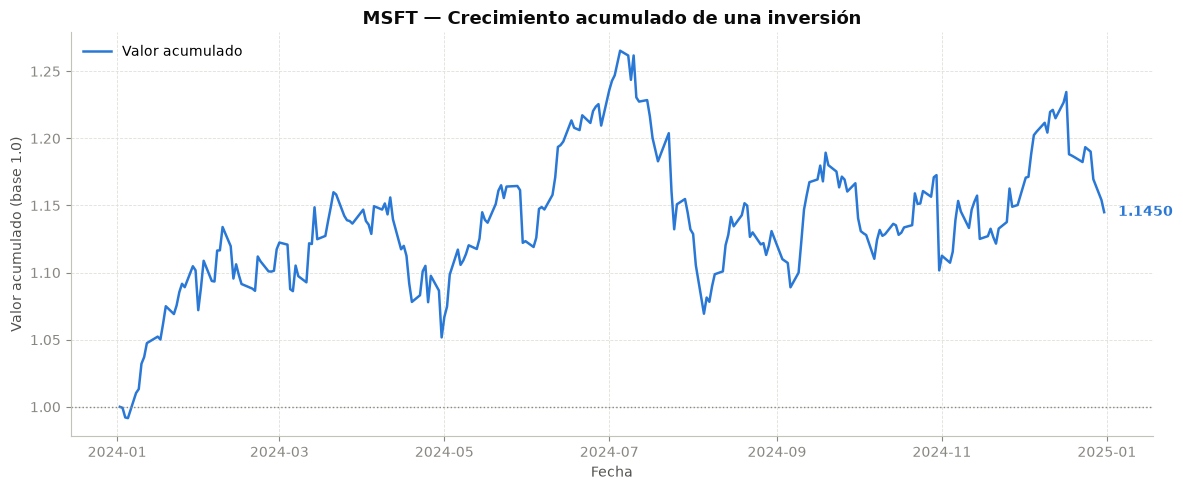

In [3]:
#Pregunta 2

ticker = "MSFT"

data = yf.download(
    ticker,
    start="2024-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False,
)

data["Return"] = data["Close"].pct_change().fillna(0)

ret_acum = 1
list_ret = []

for i in data["Return"]:
    ret_acum = ret_acum * (1 + i)
    list_ret.append(ret_acum)
    
list_ret = pd.DataFrame(list_ret,index=data.index)

#Version simplificada
#ret_acum = (1 + data["Return"].fillna(0)).cumprod()

print(f"Valor acumulado final: {ret_acum}")

plt.plot(list_ret, label="Valor acumulado", color=COLOR_PRICE)
plt.axhline(1, color="#898781", linestyle=":", linewidth=1)
plt.annotate(
    f"{ret_acum:.4f}",
    xy=(list_ret.index[-1], ret_acum),
    xytext=(10, 0),
    textcoords="offset points",
    va="center",
    color=COLOR_PRICE,
    fontweight="bold",
)
plt.title("MSFT — Crecimiento acumulado de una inversión")
plt.xlabel("Fecha")
plt.ylabel("Valor acumulado (base 1.0)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()


### Explicación

Si el último valor de `growth` fuera, por ejemplo:

$$
1.35
$$

significaría que una unidad monetaria habría crecido aproximadamente hasta:

$$
1.35
$$

es decir, un crecimiento acumulado aproximado de:

$$
35\%
$$

durante el periodo analizado.

---

# Pregunta 3 — Volatilidad diaria y anualizada

**Puntaje: 4 puntos**

Trabaje con:

```text
NVDA
```

Periodo:

```text
2024-01-01
```

hasta:

```text
2025-01-01
```

Calcule:

1. volatilidad diaria;
2. volatilidad anualizada.

Utilice:

$$
\sigma_{anual}
=
\sigma_{diaria}\sqrt{252}
$$

## Solución

In [4]:
#Pregunta 3

ticker = "NVDA"

data = yf.download(
    ticker,
    start="2024-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False,
)

data["Return"] = data["Close"].pct_change().fillna(0)

vol_diaria = np.sqrt(((data["Return"] - data["Return"].mean()) ** 2).sum() / (len(data["Return"]) - 1))

#vol_diaria = data["Return"].std()

vol_anualizada = vol_diaria * np.sqrt(252)

print(f"Volatilidad diaria: {vol_diaria * 100:.4f}%")
print(f"Volatilidad anualizada: {vol_anualizada * 100:.4f}%")



Volatilidad diaria: 3.3014%
Volatilidad anualizada: 52.4079%


### Explicación

La volatilidad diaria se obtiene como la desviación estándar de los retornos:

$$
\sigma_d=Std(R_t)
$$

La anualización utiliza aproximadamente:

$$
252
$$

ruedas bursátiles por año.

Por eso:

$$
\sigma_{anual}
=
\sigma_d\sqrt{252}
$$

---

# Pregunta 4 — Value at Risk histórico al 95 %

**Puntaje: 4 puntos**

Trabaje con:

```text
SPY
```

Periodo:

```text
2024-01-01
```

hasta:

```text
2025-01-01
```

Calcule:

1. el cuantil del 5 %;
2. el VaR histórico al 95 %;
3. el VaR monetario para un capital de 10 000.

In [5]:
#Pregunta 4

ticker = "SPY"

data = yf.download(
    ticker,
    start="2024-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False,
)

data["Return"] = data["Close"].pct_change().fillna(0)

# cresc_return = data["Return"].sort_values()
# position = (5 * (len(cresc_return) + 1))/100

# # 1. Tu posición ya calculada (12.65)
# position = (5 * (len(cresc_return) + 1)) / 100  # Da 12.65

# # 2. Python separa automáticamente la parte entera y la decimal
# # math.modf(12.65) devuelve (0.65, 12.0)
# parte_decimal, parte_entera = math.modf(position)

# # 3. Convertimos a enteros para los índices de Python (restando 1)
# idx_baja = int(parte_entera) - 1  # Posición 12 -> Índice 11
# idx_alta = idx_baja + 1           # Posición 13 -> Índice 12

# # 4. Buscamos los valores y aplicamos la fórmula de interpolación lineal a mano
# valor_12 = cresc_return.iloc[idx_baja]
# valor_13 = cresc_return.iloc[idx_alta]

# q_5 = valor_12 + parte_decimal * (valor_13 - valor_12)

#-------------------
#Version simplificada

q_5 = data["Return"].quantile(0.05)
var_95 = abs(q_5)

capital_inicial = 10000

var_mon = capital_inicial * var_95

print(f"Cuantil 5 %: {q_5 * 100:.4f}%")
print(f"VaR 95 %: {var_95 * 100:.4f}%")
print(f"VaR monetario: {var_mon:.2f}")



Cuantil 5 %: -1.3243%
VaR 95 %: 1.3243%
VaR monetario: 132.43


### Explicación

Si obtenemos, por ejemplo:

$$
q_{0.05}=-0.02
$$

entonces:

$$
VaR_{95\%}=2\%
$$

Para un capital de:

$$
10\,000
$$

tendríamos:

$$
VaR_{\text{monetario}}
=
10\,000(0.02)
=
200
$$

Este valor no representa la pérdida máxima posible. Representa un umbral histórico asociado al 5 % de los peores retornos de la muestra.

---

# Pregunta 5 — Media móvil de 20 periodos

**Puntaje: 4 puntos**

Trabaje con:

```text
AMZN
```

Periodo:

```text
2024-01-01
```

hasta:

```text
2025-01-01
```

Construya:

```python
SMA20
```

utilizando:

$$
SMA_t^{(20)}
=
\frac{1}{20}
\sum_{i=0}^{19}P_{t-i}
$$

y grafique:

- `Close`
- `SMA20`

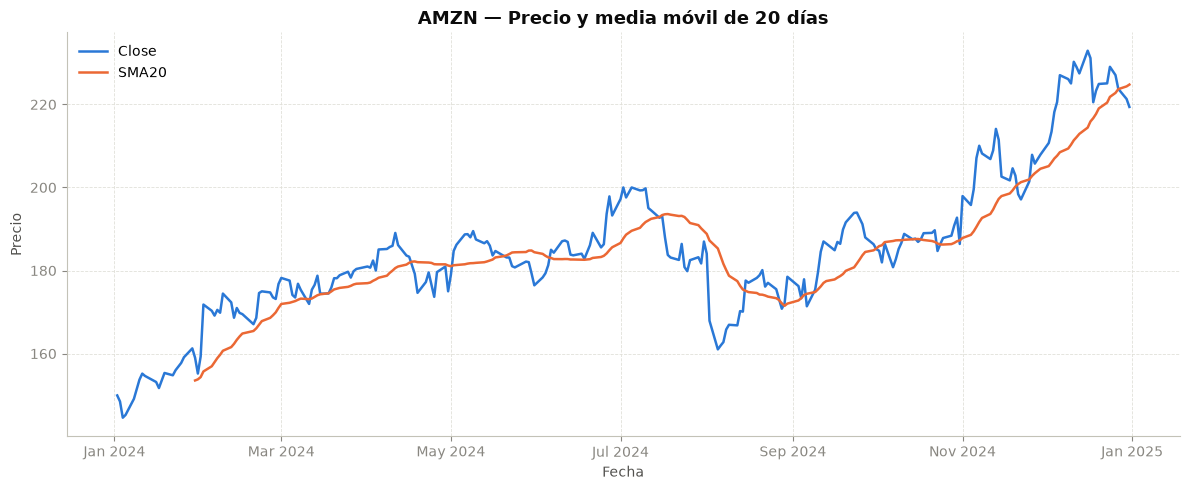

Price,Close,SMA20
Ticker,AMZN,
Date,,
2024-12-17,231.149994,215.886000
2024-12-18,220.520004,216.681500
2024-12-19,223.289993,217.702000
2024-12-20,224.919998,219.028999
2024-12-23,225.059998,220.425999
2024-12-24,229.050003,221.806000
2024-12-26,227.050003,222.765500
2024-12-27,223.750000,223.666000


In [6]:
#Pregunta 5

ticker = "AMZN"

data = yf.download(
    ticker,
    start="2024-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False,
)

data["SMA20"] = data["Close"].rolling(20).mean()

plt.plot(data["Close"], label="Close", color=COLOR_PRICE)
plt.plot(data["SMA20"], label="SMA20", color=COLOR_INDICATOR)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.title("AMZN — Precio y media móvil de 20 días")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

data[["Close", "SMA20"]].tail(10)

### Explicación

La función:

```python
rolling(20)
```

crea una ventana móvil de 20 observaciones.

Luego:

```python
.mean()
```

calcula el promedio dentro de cada ventana.

Las primeras observaciones aparecerán vacías porque todavía no existen 20 precios disponibles para realizar el cálculo.

---

# Pregunta 6 — Bandas de Bollinger

**Puntaje: 4 puntos**

Trabaje con:

```text
GOOGL
```

Periodo:

```text
2024-01-01
```

hasta:

```text
2025-01-01
```

Construya:

- `Middle`
- `STD`
- `Upper`
- `Lower`

utilizando una ventana de:

$$
20
$$

periodos y:

$$
2
$$

desviaciones estándar.

Las fórmulas son:

$$
Middle_t=SMA_{20,t}
$$

$$
Upper_t=
Middle_t+2STD_t
$$

$$
Lower_t=
Middle_t-2STD_t
$$

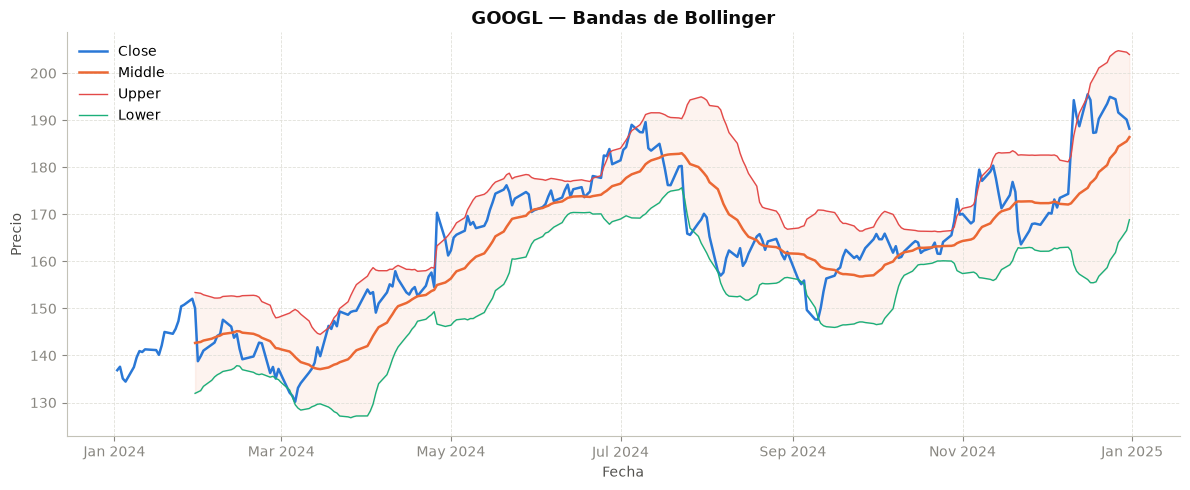

Price,Close,Mid_band,STD,Up_band,Low_band
Ticker,GOOGL,,,,
Date,,,,,
2024-12-17,194.279709,176.625410,10.577562,197.780534,155.470287
2024-12-18,187.300659,177.146547,10.844055,198.834657,155.458437
2024-12-19,187.410019,177.779405,11.064110,199.907625,155.651186
2024-12-20,190.293106,178.971008,11.064322,201.099652,156.842363
2024-12-23,193.494339,180.465171,10.897403,202.259976,158.670366
2024-12-24,194.965683,181.889407,10.834768,203.558944,160.219870
2024-12-26,194.458664,183.215306,10.659099,204.533503,161.897109
2024-12-27,191.635239,184.394572,10.187207,204.768985,164.020158


In [7]:
#Pregunta 6

ticker = "GOOGL"

data = yf.download(
    ticker,
    start="2024-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False,
)

data["Mid_band"] = data["Close"].rolling(20).mean()
data["STD"] = data["Close"].rolling(window=20).std()
data["Up_band"] = data["Mid_band"] + (2 * data["STD"])
data["Low_band"] = data["Mid_band"] + (-2 * data["STD"])

plt.plot(data["Close"], label="Close", color=COLOR_PRICE)
plt.plot(data["Mid_band"], label="Middle", color=COLOR_INDICATOR)
plt.plot(data["Up_band"], label="Upper", color=COLOR_UPPER, linewidth=1)
plt.plot(data["Low_band"], label="Lower", color=COLOR_LOWER, linewidth=1)
plt.fill_between(data.index, data["Up_band"], data["Low_band"], color=COLOR_INDICATOR, alpha=0.08)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.title("GOOGL — Bandas de Bollinger")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

data[["Close", "Mid_band", "STD", "Up_band", "Low_band"]].tail(10)

### Explicación

Las Bandas de Bollinger combinan:

$$
\text{media móvil}
$$

con:

$$
\text{desviación estándar móvil}
$$

Cuando la dispersión reciente del precio aumenta, las bandas tienden a separarse.

Cuando disminuye, las bandas tienden a acercarse.

En este ejercicio no estamos construyendo una estrategia de compra o venta. Solamente estamos calculando y visualizando el indicador.

---

# Resumen de respuestas

| Pregunta | Tema | Puntaje |
|---|---|---:|
| 1 | Retornos simples | 4 |
| 2 | Crecimiento acumulado | 4 |
| 3 | Volatilidad | 4 |
| 4 | VaR histórico | 4 |
| 5 | Media móvil | 4 |
| 6 | Bandas de Bollinger | 4 |
| **Total bruto** |  | **24** |
| **Nota máxima registrada** |  | **20** |

$$
\boxed{
\text{Nota final}
=
\min(\text{Puntaje obtenido},20)
}
$$

## Criterio general de corrección

En cada pregunta puede considerarse:

- código correctamente estructurado;
- uso de la función solicitada;
- resultado ejecutable;
- gráfico correcto cuando corresponda.